In [369]:
from sklearn.neural_network import MLPClassifier
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.cluster import KMeans as Kmeans
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
import mglearn

In [370]:
df = pd.read_csv("/home/licongcong/Desktop/learning/medical_image_classification/BrainCanerSurvival/result/merge_df.csv")
df.head()

,patient_id,__label,__row_index,CDE_survival_time,CDE_survival_time_bin,CALB2,FMO2,PHEX,PFN2,RAD23A,...,PARP2,PRNP,PLEC,COX6C,ELOVL6,TIMP1,CNDP2,SLCO4C1,CYP4F2,BATF3
0,TCGA-2F-A9KO,2,0,24.466667,2,-4.2934,0.0014,0.9493,6.5729,6.6168,...,4.4270,5.6303,4.8192,8.8139,2.7487,9.2370,7.8170,-1.3548,-2.1140,0.6790
1,TCGA-2F-A9KP,1,1,12.133333,1,-3.4580,-6.5064,-3.8160,6.8869,6.7848,...,3.7345,6.6160,4.7825,8.8032,4.5015,7.0465,6.9948,-2.2447,-1.1488,0.1257
2,TCGA-2F-A9KP,1,2,12.133333,1,-3.4580,-6.5064,-3.8160,6.8869,6.7848,...,3.7345,6.6160,4.7825,8.8032,4.5015,7.0465,6.9948,-2.2447,-1.1488,0.1257
3,TCGA-2F-A9KQ,3,3,96.200000,3,-2.1779,-9.9658,-2.7274,6.8235,6.5334,...,3.6782,5.4601,4.6933,8.9009,3.8330,8.2687,5.7722,-5.5735,1.0983,0.4447
4,TCGA-2F-A9KR,3,4,106.100000,3,-1.7322,-0.7834,-0.0425,7.1994,7.0583,...,4.0926,6.5336,6.3658,9.5826,3.0199,8.4986,7.0546,-2.3147,-2.0529,-0.3022


In [371]:
df.groupby("__label").size()

__label
0    106
1    106
2    105
3    106
dtype: int64

In [372]:
x = df.drop(columns=["__label", "__row_index", "CDE_survival_time", "CDE_survival_time_bin", "patient_id"])
x.head()

,CALB2,FMO2,PHEX,PFN2,RAD23A,COX10,IL32,ST3GAL6,PKP2,KRT1,...,PARP2,PRNP,PLEC,COX6C,ELOVL6,TIMP1,CNDP2,SLCO4C1,CYP4F2,BATF3
0,-4.2934,0.0014,0.9493,6.5729,6.6168,2.7095,7.3978,0.5470,1.9712,2.6602,...,4.4270,5.6303,4.8192,8.8139,2.7487,9.2370,7.8170,-1.3548,-2.1140,0.6790
1,-3.4580,-6.5064,-3.8160,6.8869,6.7848,3.8401,2.4359,-1.7322,3.3993,0.3685,...,3.7345,6.6160,4.7825,8.8032,4.5015,7.0465,6.9948,-2.2447,-1.1488,0.1257
2,-3.4580,-6.5064,-3.8160,6.8869,6.7848,3.8401,2.4359,-1.7322,3.3993,0.3685,...,3.7345,6.6160,4.7825,8.8032,4.5015,7.0465,6.9948,-2.2447,-1.1488,0.1257
3,-2.1779,-9.9658,-2.7274,6.8235,6.5334,2.7292,3.5863,-1.1172,-1.2481,-2.1779,...,3.6782,5.4601,4.6933,8.9009,3.8330,8.2687,5.7722,-5.5735,1.0983,0.4447
4,-1.7322,-0.7834,-0.0425,7.1994,7.0583,2.2573,4.6023,-0.3201,2.1606,6.8280,...,4.0926,6.5336,6.3658,9.5826,3.0199,8.4986,7.0546,-2.3147,-2.0529,-0.3022


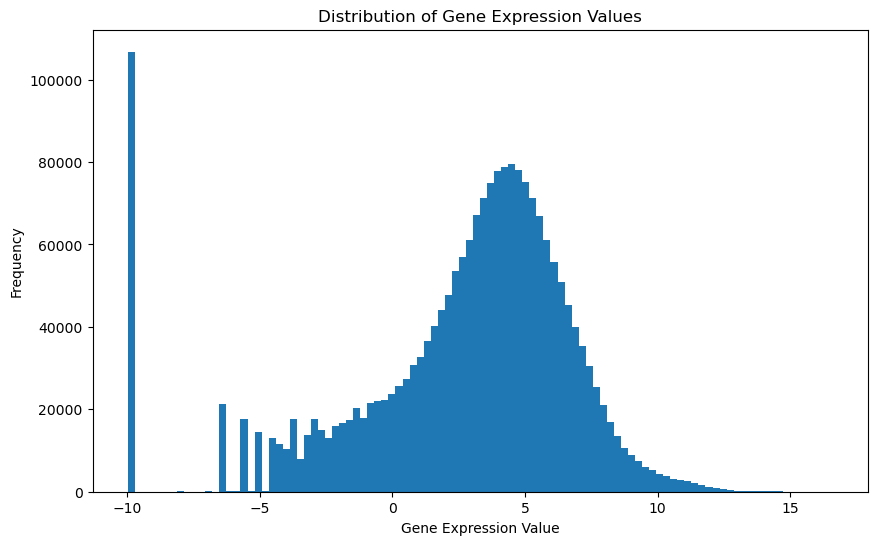

In [373]:

all_values = x.values.flatten()

# Plot histogram
plt.figure(figsize=(10, 6))

plt.hist(all_values, bins=100)

plt.xlabel("Gene Expression Value")
plt.ylabel("Frequency")
plt.title("Distribution of Gene Expression Values")

plt.show()

In [374]:
# x = np.log2(x + 1)

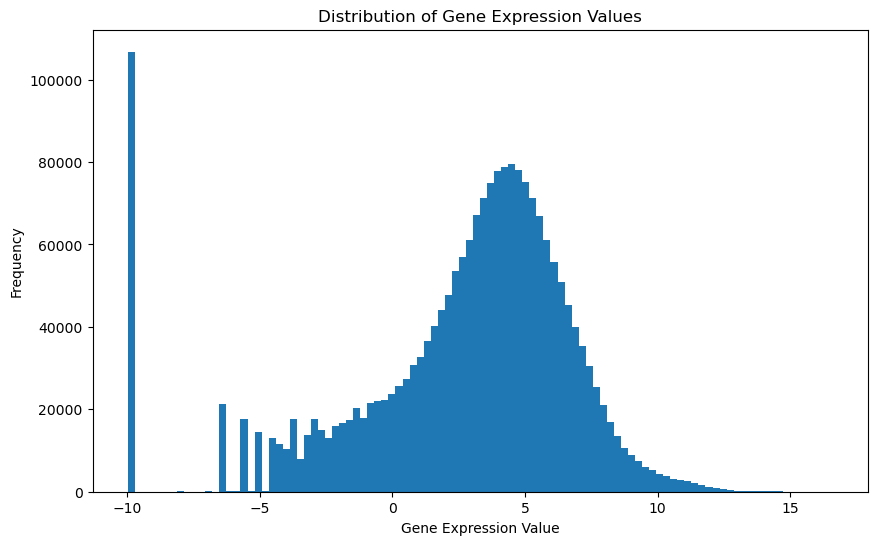

In [375]:
all_values = x.values.flatten()

# Plot histogram
plt.figure(figsize=(10, 6))

plt.hist(all_values, bins=100)

plt.xlabel("Gene Expression Value")
plt.ylabel("Frequency")
plt.title("Distribution of Gene Expression Values")

plt.show()

In [376]:
# scaler = StandardScaler()
# x = scaler.fit_transform(x)
# x = np.round(x, 4)
# #change numpy to dataframe
# x = pd.DataFrame(x)

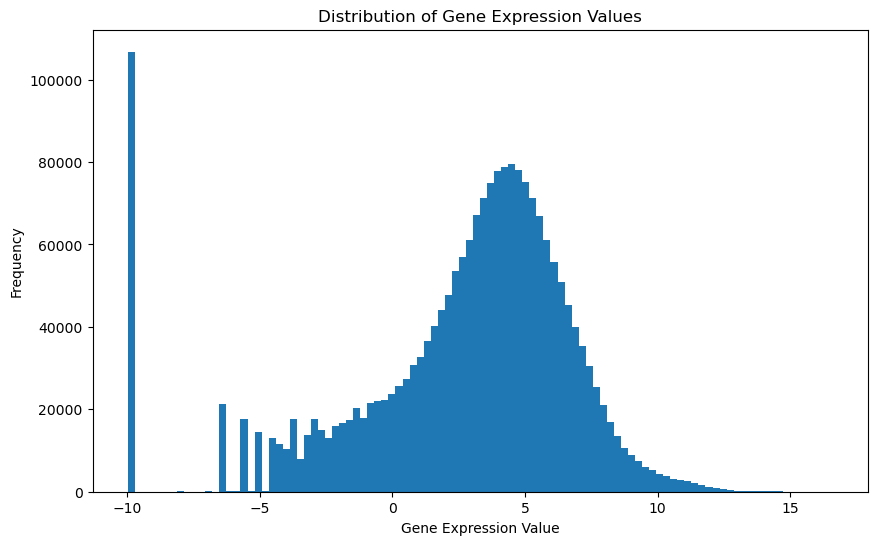

In [377]:
all_values = x.values.flatten()

# Plot histogram
plt.figure(figsize=(10, 6))

plt.hist(all_values, bins=100)

plt.xlabel("Gene Expression Value")
plt.ylabel("Frequency")
plt.title("Distribution of Gene Expression Values")

plt.show()

In [378]:
x.head()

,CALB2,FMO2,PHEX,PFN2,RAD23A,COX10,IL32,ST3GAL6,PKP2,KRT1,...,PARP2,PRNP,PLEC,COX6C,ELOVL6,TIMP1,CNDP2,SLCO4C1,CYP4F2,BATF3
0,-4.2934,0.0014,0.9493,6.5729,6.6168,2.7095,7.3978,0.5470,1.9712,2.6602,...,4.4270,5.6303,4.8192,8.8139,2.7487,9.2370,7.8170,-1.3548,-2.1140,0.6790
1,-3.4580,-6.5064,-3.8160,6.8869,6.7848,3.8401,2.4359,-1.7322,3.3993,0.3685,...,3.7345,6.6160,4.7825,8.8032,4.5015,7.0465,6.9948,-2.2447,-1.1488,0.1257
2,-3.4580,-6.5064,-3.8160,6.8869,6.7848,3.8401,2.4359,-1.7322,3.3993,0.3685,...,3.7345,6.6160,4.7825,8.8032,4.5015,7.0465,6.9948,-2.2447,-1.1488,0.1257
3,-2.1779,-9.9658,-2.7274,6.8235,6.5334,2.7292,3.5863,-1.1172,-1.2481,-2.1779,...,3.6782,5.4601,4.6933,8.9009,3.8330,8.2687,5.7722,-5.5735,1.0983,0.4447
4,-1.7322,-0.7834,-0.0425,7.1994,7.0583,2.2573,4.6023,-0.3201,2.1606,6.8280,...,4.0926,6.5336,6.3658,9.5826,3.0199,8.4986,7.0546,-2.3147,-2.0529,-0.3022


In [379]:
y = df["__label"]
y.head()

0    2
1    1
2    1
3    3
4    3
Name: __label, dtype: int64

In [380]:
X_train, X_test, y_train, y_test = train_test_split(x, y,test_size = 0.2, random_state = 42)

In [381]:
mlp = MLPClassifier(solver='lbfgs', random_state=42)
mlp.fit(X_train, y_train)

,hidden_layer_sizes,"(100,)"
,activation,'relu'
,solver,'lbfgs'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,200
,shuffle,True
,random_state,42


In [382]:
y_train_pred = mlp.predict(X_train)
y_test_pred = mlp.predict(X_test)

In [383]:
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)
print(f"train acc: {train_acc:.4f}, test acc: {test_acc:.4f}")

train acc: 1.0000, test acc: 0.4588


In [384]:
mlp_act = MLPClassifier(activation='relu', solver='lbfgs', max_iter=5000, random_state=42, batch_size=32, learning_rate_init=0.0001)
mlp_act.fit(X_train, y_train)

,hidden_layer_sizes,"(100,)"
,activation,'relu'
,solver,'lbfgs'
,alpha,0.0001
,batch_size,32
,learning_rate,'constant'
,learning_rate_init,0.0001
,power_t,0.5
,max_iter,5000
,shuffle,True
,random_state,42


In [385]:
y_train_pred = mlp_act.predict(X_train)
y_test_pred = mlp_act.predict(X_test)

In [386]:
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)
print(f"train acc: {train_acc:.4f}, test acc: {test_acc:.4f}")

train acc: 1.0000, test acc: 0.4588


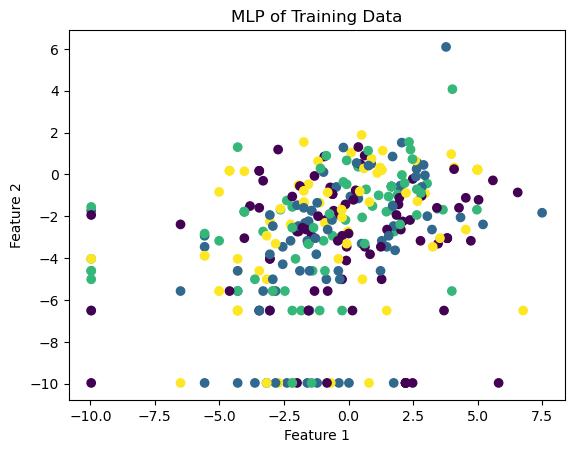

In [387]:
plt.scatter(X_train.iloc[:, 0], X_train.iloc[:, 1], c=y_train_pred, cmap='viridis')
plt.title("MLP of Training Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [388]:
model = Kmeans(n_clusters=4, random_state=42)
model.fit(X_train)

,n_clusters,4
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [389]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)


In [390]:
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)
print(f"train acc: {train_acc:.4f}, test acc: {test_acc:.4f}")

train acc: 0.2426, test acc: 0.2471


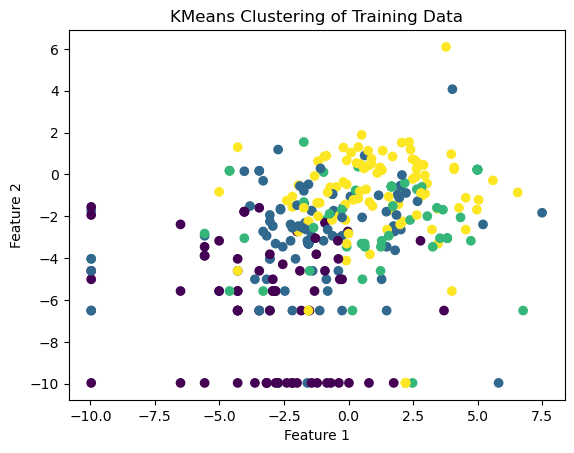

In [391]:
plt.scatter(X_train.iloc[:, 0], X_train.iloc[:, 1], c=y_train_pred, cmap='viridis')
plt.title("KMeans Clustering of Training Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

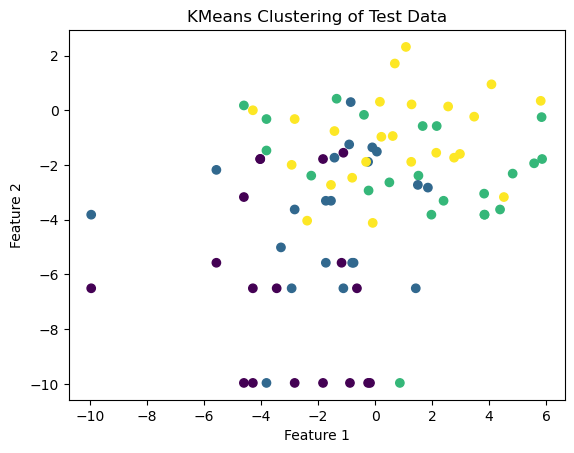

In [392]:
plt.scatter(X_test.iloc[:, 0], X_test.iloc[:, 1], c=y_test_pred, cmap='viridis')
plt.title("KMeans Clustering of Test Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [393]:
blca = pd.read_csv("/home/licongcong/Desktop/learning/medical_image_classification/BrainCanerSurvival/result/merge_df.csv")
blca.head()

,patient_id,__label,__row_index,CDE_survival_time,CDE_survival_time_bin,CALB2,FMO2,PHEX,PFN2,RAD23A,...,PARP2,PRNP,PLEC,COX6C,ELOVL6,TIMP1,CNDP2,SLCO4C1,CYP4F2,BATF3
0,TCGA-2F-A9KO,2,0,24.466667,2,-4.2934,0.0014,0.9493,6.5729,6.6168,...,4.4270,5.6303,4.8192,8.8139,2.7487,9.2370,7.8170,-1.3548,-2.1140,0.6790
1,TCGA-2F-A9KP,1,1,12.133333,1,-3.4580,-6.5064,-3.8160,6.8869,6.7848,...,3.7345,6.6160,4.7825,8.8032,4.5015,7.0465,6.9948,-2.2447,-1.1488,0.1257
2,TCGA-2F-A9KP,1,2,12.133333,1,-3.4580,-6.5064,-3.8160,6.8869,6.7848,...,3.7345,6.6160,4.7825,8.8032,4.5015,7.0465,6.9948,-2.2447,-1.1488,0.1257
3,TCGA-2F-A9KQ,3,3,96.200000,3,-2.1779,-9.9658,-2.7274,6.8235,6.5334,...,3.6782,5.4601,4.6933,8.9009,3.8330,8.2687,5.7722,-5.5735,1.0983,0.4447
4,TCGA-2F-A9KR,3,4,106.100000,3,-1.7322,-0.7834,-0.0425,7.1994,7.0583,...,4.0926,6.5336,6.3658,9.5826,3.0199,8.4986,7.0546,-2.3147,-2.0529,-0.3022


In [394]:
blca_x = blca.drop(columns=["patient_id", "__row_index", "CDE_survival_time", "CDE_survival_time_bin","__label"])
blca_x.head()

,CALB2,FMO2,PHEX,PFN2,RAD23A,COX10,IL32,ST3GAL6,PKP2,KRT1,...,PARP2,PRNP,PLEC,COX6C,ELOVL6,TIMP1,CNDP2,SLCO4C1,CYP4F2,BATF3
0,-4.2934,0.0014,0.9493,6.5729,6.6168,2.7095,7.3978,0.5470,1.9712,2.6602,...,4.4270,5.6303,4.8192,8.8139,2.7487,9.2370,7.8170,-1.3548,-2.1140,0.6790
1,-3.4580,-6.5064,-3.8160,6.8869,6.7848,3.8401,2.4359,-1.7322,3.3993,0.3685,...,3.7345,6.6160,4.7825,8.8032,4.5015,7.0465,6.9948,-2.2447,-1.1488,0.1257
2,-3.4580,-6.5064,-3.8160,6.8869,6.7848,3.8401,2.4359,-1.7322,3.3993,0.3685,...,3.7345,6.6160,4.7825,8.8032,4.5015,7.0465,6.9948,-2.2447,-1.1488,0.1257
3,-2.1779,-9.9658,-2.7274,6.8235,6.5334,2.7292,3.5863,-1.1172,-1.2481,-2.1779,...,3.6782,5.4601,4.6933,8.9009,3.8330,8.2687,5.7722,-5.5735,1.0983,0.4447
4,-1.7322,-0.7834,-0.0425,7.1994,7.0583,2.2573,4.6023,-0.3201,2.1606,6.8280,...,4.0926,6.5336,6.3658,9.5826,3.0199,8.4986,7.0546,-2.3147,-2.0529,-0.3022


In [395]:
blca_y = blca["__label"]
blca_y.head()

0    2
1    1
2    1
3    3
4    3
Name: __label, dtype: int64

In [396]:
X_train, X_test, y_train, y_test = train_test_split(blca_x, blca_y, test_size = 0.25,random_state=42)

In [397]:
mlp = MLPClassifier(solver='lbfgs', random_state=42)
mlp.fit(X_train, y_train)
y_train_pred = mlp.predict(X_train)
y_test_pred = mlp.predict(X_test)
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

In [398]:
print(train_acc, test_acc)

1.0 0.4716981132075472
